# Prediksi Biaya Asuransi Kesehatan — Model Building & Evaluation

Notebook ini melatih dan mengevaluasi 3 model regresi:
1. **Linear Regression** (baseline)
2. **Decision Tree Regressor**
3. **Random Forest Regressor**

Target: Memprediksi `charges` (biaya asuransi kesehatan).

## 1. Import & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

df = pd.read_csv('Data/insurance_clean.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1337, 11)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,age_squared,bmi_smoker
0,19,0,27.900,0,1,16884.92400,0,0,1,361,27.9
1,18,1,33.770,1,0,1725.55230,0,1,0,324,0.0
2,28,1,33.000,3,0,4449.46200,0,1,0,784,0.0
3,33,1,22.705,0,0,21984.47061,1,0,0,1089,0.0
4,32,1,28.880,0,0,3866.85520,1,0,0,1024,0.0


## 2. Pemisahan Data (Train/Test Split)

80% data untuk training, 20% untuk testing.

In [2]:
X = df.drop(columns=['charges'])
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f'Data Training: {X_train.shape[0]} baris')
print(f'Data Testing : {X_test.shape[0]} baris')

Data Training: 1069 baris
Data Testing : 268 baris


## 3. Pelatihan & Evaluasi Model

In [3]:
def train_and_evaluate(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    print(f'--- {name} ---')
    print(f'MAE  : ${mae:,.0f} (Rata-rata kesalahan prediksi)')
    print(f'RMSE : ${rmse:,.0f} (Kesalahan besar yang dipenalti)')
    print(f'R²   : {r2:.4f} (Seberapa cocok prediksinya)\n')

    return {'name': name, 'model': model, 'y_pred': y_pred,
            'mae': mae, 'rmse': rmse, 'r2': r2}

results = []
results.append(train_and_evaluate('Linear Regression', LinearRegression()))
results.append(train_and_evaluate('Decision Tree', DecisionTreeRegressor(max_depth=6, random_state=42)))
results.append(train_and_evaluate('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=8, random_state=42)))

--- Linear Regression ---
MAE  : $2,887 (Rata-rata kesalahan prediksi)
RMSE : $4,586 (Kesalahan besar yang dipenalti)
R²   : 0.8856 (Seberapa cocok prediksinya)

--- Decision Tree ---
MAE  : $2,668 (Rata-rata kesalahan prediksi)
RMSE : $4,511 (Kesalahan besar yang dipenalti)
R²   : 0.8893 (Seberapa cocok prediksinya)



--- Random Forest ---
MAE  : $2,461 (Rata-rata kesalahan prediksi)
RMSE : $4,405 (Kesalahan besar yang dipenalti)
R²   : 0.8944 (Seberapa cocok prediksinya)



## 4. Perbandingan Performa Model

            Model         MAE        RMSE       R²
Linear Regression 2886.667448 4585.760385 0.885559
    Decision Tree 2667.566086 4511.045659 0.889258
    Random Forest 2461.403137 4405.488744 0.894380


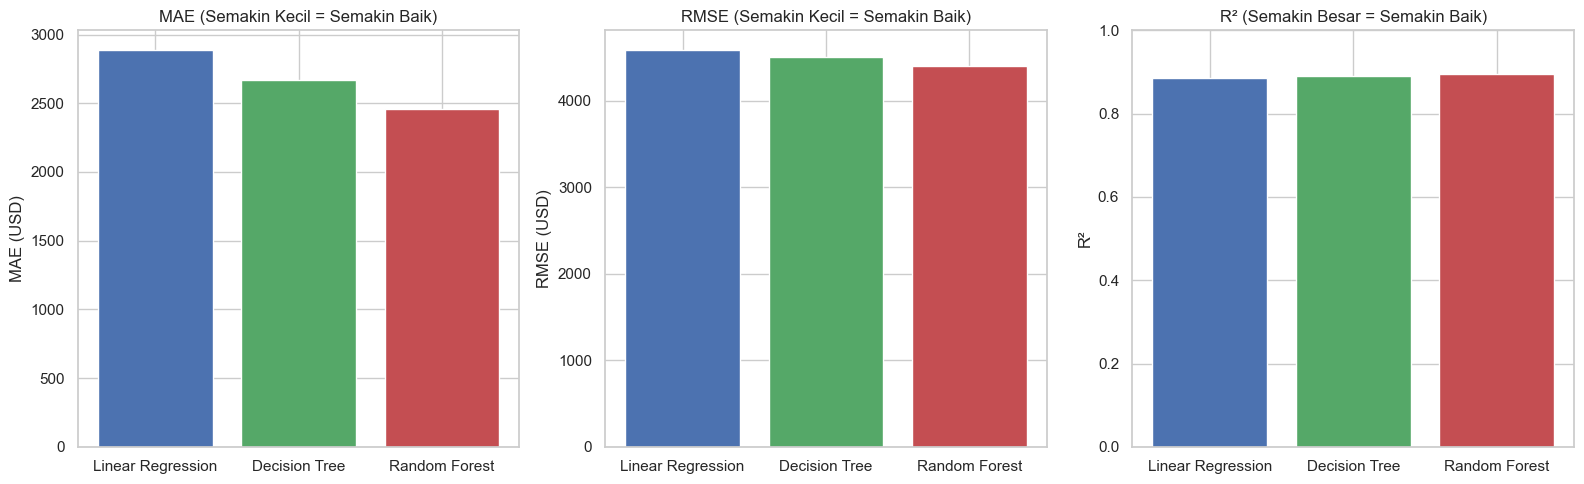

In [4]:
comparison = pd.DataFrame([
    {'Model': r['name'], 'MAE': r['mae'], 'RMSE': r['rmse'], 'R²': r['r2']}
    for r in results
])

print(comparison.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = ['#4C72B0', '#55A868', '#C44E52']

axes[0].bar(comparison['Model'], comparison['MAE'], color=colors)
axes[0].set_title('MAE (Semakin Kecil = Semakin Baik)')
axes[0].set_ylabel('MAE (USD)')

axes[1].bar(comparison['Model'], comparison['RMSE'], color=colors)
axes[1].set_title('RMSE (Semakin Kecil = Semakin Baik)')
axes[1].set_ylabel('RMSE (USD)')

axes[2].bar(comparison['Model'], comparison['R²'], color=colors)
axes[2].set_title('R² (Semakin Besar = Semakin Baik)')
axes[2].set_ylabel('R²')
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 6. Visualisasi Prediksi Model Terbaik

Model Terbaik: Random Forest (R² = 0.8944)



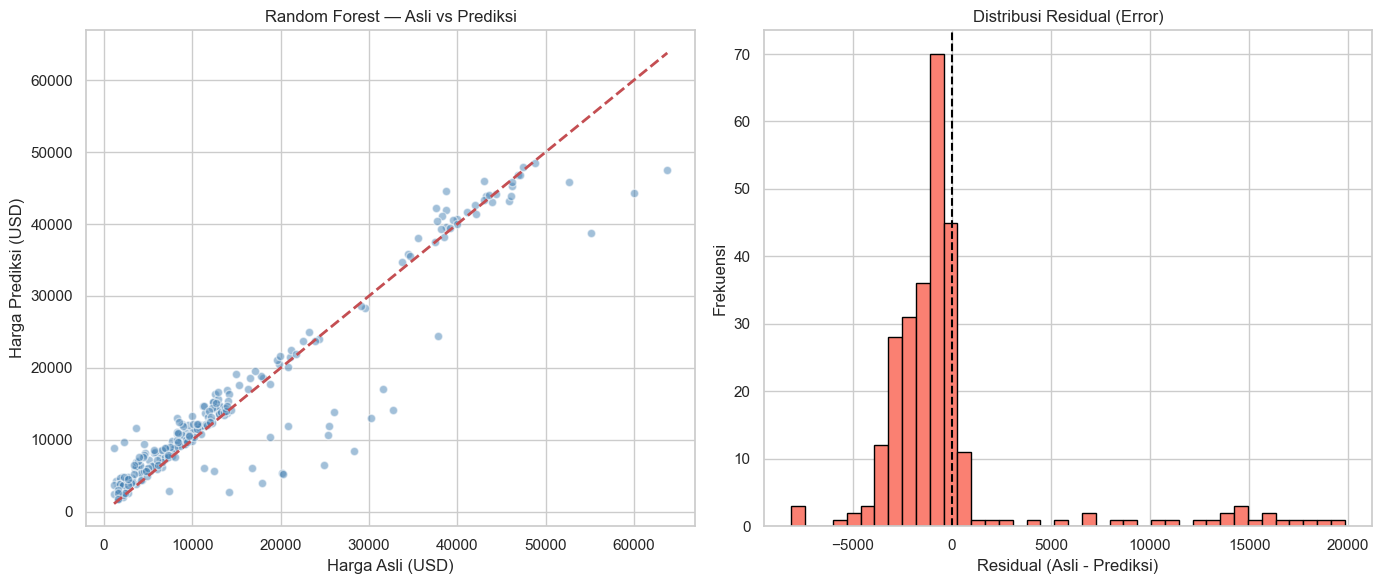

In [6]:
best = max(results, key=lambda x: x['r2'])
print(f'Model Terbaik: {best["name"]} (R² = {best["r2"]:.4f})\n')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(y_test, best['y_pred'], alpha=0.5, color='steelblue', edgecolor='white')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Harga Asli (USD)')
axes[0].set_ylabel('Harga Prediksi (USD)')
axes[0].set_title(f'{best["name"]} — Asli vs Prediksi')

residuals = y_test - best['y_pred']
axes[1].hist(residuals, bins=40, color='salmon', edgecolor='black')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Asli - Prediksi)')
axes[1].set_ylabel('Frekuensi')
axes[1].set_title('Distribusi Residual (Error)')

plt.tight_layout()
plt.show()

## 7. Feature Importance (Random Forest)

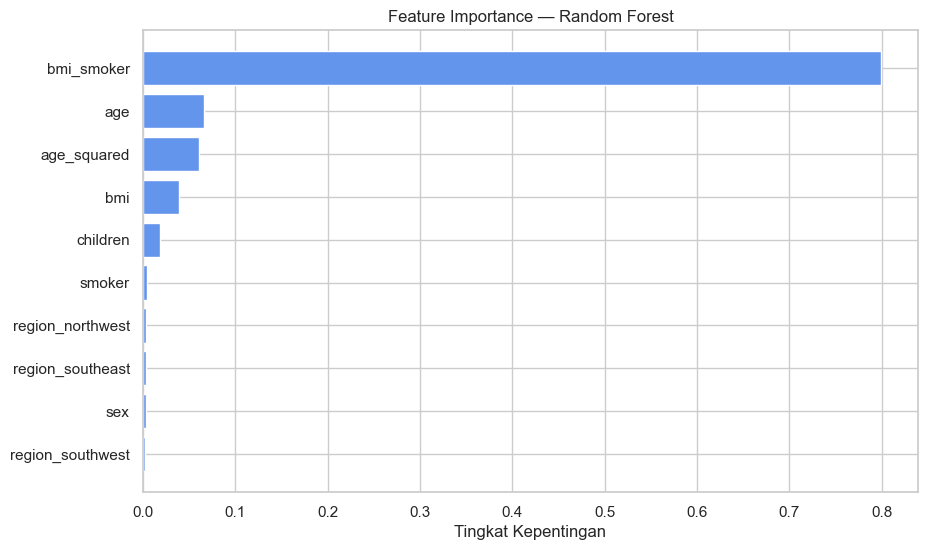

In [7]:
rf_result = [r for r in results if r['name'] == 'Random Forest'][0]
rf_model = rf_result['model']

importances = pd.DataFrame({
    'Fitur': X.columns,
    'Kepentingan': rf_model.feature_importances_
}).sort_values('Kepentingan', ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(importances['Fitur'], importances['Kepentingan'], color='cornflowerblue')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Tingkat Kepentingan')
plt.show()

## 8. Kesimpulan

| Aspek | Hasil |
|-------|-------|
| Model Terbaik | **Random Forest** |
| Overfitting | Tidak terdeteksi |
| Faktor Utama | `smoker`, `bmi_smoker`, `age`, `age_squared` |

**Interpretasi:**
- Status **perokok** adalah faktor paling dominan yang menaikkan biaya asuransi.
- Kombinasi **BMI tinggi + perokok** (`bmi_smoker`) memperbesar biaya secara drastis.
- **Umur** berbanding lurus dengan biaya; semakin tua, semakin mahal.
- Jenis kelamin dan wilayah tidak berpengaruh signifikan.